In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

In [2]:
soccer = pd.read_csv('../output/csvs/soccer_generalized_cscores.csv')
soccer

,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3,n1*,c1*,n2*,c2*
0,Bundesliga,2000,Bayern Munich,"[1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, ...",28,14,14,19,9,10,1.414208,1.521762,1.233046,10,2.449470,10.0,3.944894
1,Bundesliga,2000,Bochum,"[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, ...",28,14,14,7,5,2,3.557103,10.502532,4.975124,5,4.213992,5.0,12.959781
2,Bundesliga,2000,Cottbus,"[0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, ...",31,16,15,12,6,6,1.540103,1.796042,1.443001,13,1.633396,13.0,2.039216
3,Bundesliga,2000,Dortmund,"[1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",24,12,12,16,7,9,1.221184,1.239523,1.118568,8,1.880482,5.0,2.768998
4,Bundesliga,2000,Ein Frankfurt,"[1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, ...",29,15,14,10,6,4,2.278359,3.863890,2.433090,10,3.663872,10.0,8.551127
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1433,La_Liga,2024,Sociedad,"[0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, ...",31,16,15,13,8,5,2.899686,5.758226,3.367003,6,4.892563,6.0,12.309017
1434,La_Liga,2024,Valencia,"[0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, ...",25,13,12,11,3,8,1.031319,1.014335,1.003009,2,3.188776,2.0,10.458316
1435,La_Liga,2024,Valladolid,"[1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, ...",34,17,17,4,4,0,8.396151,60.167004,19.872814,17,8.396151,17.0,60.167004
1436,La_Liga,2024,Vallecano,"[1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",25,13,12,13,7,6,1.793021,2.359879,1.686341,10,3.041173,10.0,6.119959


In [3]:
us_leagues = pd.read_csv('../output/csvs/us_generalized_cscores.csv')
us_leagues

,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3,n1*,c1*,n2*,c2*
0,NBA,2015,Orlando Magic,"[0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, ...",82,41,41,35,20,15,3.764011,7.567749,5.617978,41,3.764011,41,7.567749
1,NBA,2015,Houston Rockets,"[0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, ...",82,41,41,41,21,20,2.000000,2.423658,2.057613,35,2.717839,35,3.976260
2,NBA,2015,Oklahoma City Thunder,"[1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, ...",82,41,41,55,29,26,2.749747,4.159434,3.300330,8,11.926959,8,32.797102
3,NBA,2015,Sacramento Kings,"[0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, ...",82,41,41,33,18,15,2.639310,4.005520,3.105590,39,4.190481,39,8.918303
4,NBA,2015,Utah Jazz,"[0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, ...",82,41,41,40,18,22,1.277825,1.232172,1.136364,5,4.923305,2,12.320543
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4318,NBA,1982,Indiana Pacers,"[1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, ...",82,41,41,20,13,7,5.464184,16.280440,9.009009,37,12.046809,37,53.259359
4319,NBA,1982,Washington Bullets,"[0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, ...",82,41,41,42,18,24,1.158671,1.101917,1.064963,3,2.075934,1,6.610688
4320,NBA,1982,Dallas Mavericks,"[1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, ...",82,41,41,38,19,19,1.774389,2.000000,1.808318,11,18.279912,11,45.312997
4321,NBA,1982,Denver Nuggets,"[0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, ...",82,41,41,45,19,26,1.115894,1.064008,1.047120,15,1.812723,15,2.236664


In [4]:
soccer['n2*'].value_counts().reset_index()

,n2*,count
0,1.0,239
1,2.0,170
2,3.0,122
3,7.0,94
4,6.0,94
5,5.0,91
6,4.0,90
7,8.0,87
8,11.0,79
9,9.0,79


In [5]:
soccer['normalized_n2*'] = soccer['n2*']/soccer['n']
soccer

,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3,n1*,c1*,n2*,c2*,normalized_n2*
0,Bundesliga,2000,Bayern Munich,"[1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, ...",28,14,14,19,9,10,1.414208,1.521762,1.233046,10,2.449470,10.0,3.944894,0.357143
1,Bundesliga,2000,Bochum,"[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, ...",28,14,14,7,5,2,3.557103,10.502532,4.975124,5,4.213992,5.0,12.959781,0.178571
2,Bundesliga,2000,Cottbus,"[0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, ...",31,16,15,12,6,6,1.540103,1.796042,1.443001,13,1.633396,13.0,2.039216,0.419355
3,Bundesliga,2000,Dortmund,"[1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",24,12,12,16,7,9,1.221184,1.239523,1.118568,8,1.880482,5.0,2.768998,0.208333
4,Bundesliga,2000,Ein Frankfurt,"[1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, ...",29,15,14,10,6,4,2.278359,3.863890,2.433090,10,3.663872,10.0,8.551127,0.344828
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1433,La_Liga,2024,Sociedad,"[0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, ...",31,16,15,13,8,5,2.899686,5.758226,3.367003,6,4.892563,6.0,12.309017,0.193548
1434,La_Liga,2024,Valencia,"[0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, ...",25,13,12,11,3,8,1.031319,1.014335,1.003009,2,3.188776,2.0,10.458316,0.080000
1435,La_Liga,2024,Valladolid,"[1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, ...",34,17,17,4,4,0,8.396151,60.167004,19.872814,17,8.396151,17.0,60.167004,0.500000
1436,La_Liga,2024,Vallecano,"[1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",25,13,12,13,7,6,1.793021,2.359879,1.686341,10,3.041173,10.0,6.119959,0.400000


In [6]:
soccer['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,1433.000000
1,mean,0.229465
2,std,0.155140
3,min,0.027778
4,25%,0.080000
5,50%,0.206897
6,75%,0.370370
7,max,0.500000


# Soccer Analysis

## N2* Summary Statistics

### Overall Across All Leagues

In [10]:
soccer_n2_counts = soccer['n2*'].value_counts().reset_index()
soccer_n2_counts

,n2*,count
0,1.0,239
1,2.0,170
2,3.0,122
3,7.0,94
4,6.0,94
5,5.0,91
6,4.0,90
7,8.0,87
8,11.0,79
9,9.0,79


In [11]:
soccer_n2_summary = soccer['n2*'].describe().reset_index()
soccer_n2_summary

,index,n2*
0,count,1433.000000
1,mean,6.177251
2,std,4.291652
3,min,1.000000
4,25%,2.000000
5,50%,6.000000
6,75%,10.000000
7,max,17.000000


#### Premier League

In [13]:
pl_soccer = soccer[soccer['League']=='Premier_League']
pl_soccer

,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3,n1*,c1*,n2*,c2*,normalized_n2*
451,Premier_League,2000,Arsenal,"[0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, ...",28,14,14,20,10,10,1.666866,2.000000,1.555210,1,3.500000,1.0,18.628137,0.035714
452,Premier_League,2000,Aston Villa,"[0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, ...",23,12,11,13,7,6,1.778085,2.339846,1.689189,1,2.300000,1.0,8.206977,0.043478
453,Premier_League,2000,Bradford,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, ...",27,14,13,5,2,3,1.263532,1.385821,1.193317,3,1.848516,3.0,5.247517,0.111111
454,Premier_League,2000,Charlton,"[1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, ...",28,14,14,14,6,8,1.268995,1.290066,1.128668,2,4.000000,2.0,14.063388,0.071429
455,Premier_League,2000,Chelsea,"[1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, ...",28,14,14,17,7,10,1.157062,1.140055,1.067236,4,1.951518,4.0,3.146842,0.142857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
950,Premier_League,2024,Nottm Forest,"[1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1]",13,7,6,9,5,4,1.677028,2.345006,1.488095,6,1.677028,6.0,2.345006,0.461538
951,Premier_League,2024,Southampton,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...",32,16,16,2,1,1,1.358905,2.000000,1.305483,11,2.033836,11.0,6.885488,0.343750
952,Premier_League,2024,Tottenham,"[1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, ...",33,17,16,11,7,4,2.948780,6.162692,3.649635,6,11.390625,6.0,36.028832,0.181818
953,Premier_League,2024,West Ham,"[0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, ...",28,14,14,11,6,5,1.968326,2.862086,1.984127,7,2.295970,7.0,3.978388,0.250000


In [14]:
pl_n2_counts = pl_soccer['n2*'].value_counts().reset_index()
pl_n2_counts

,n2*,count
0,1.0,83
1,2.0,58
2,3.0,49
3,7.0,37
4,5.0,32
5,6.0,32
6,8.0,29
7,10.0,29
8,4.0,28
9,9.0,26


In [15]:
pl_n2_summary = pl_soccer['n2*'].describe().reset_index()
pl_n2_summary

,index,n2*
0,count,502.000000
1,mean,6.179283
2,std,4.332458
3,min,1.000000
4,25%,2.000000
5,50%,6.000000
6,75%,10.000000
7,max,17.000000


### La Liga

In [17]:
la_liga_soccer = soccer[soccer['League']=='La_Liga']
la_liga_soccer

,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3,n1*,c1*,n2*,c2*,normalized_n2*
955,La_Liga,2000,Alaves,"[1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, ...",31,16,15,14,7,7,1.541379,1.770633,1.420455,5,20.163404,5.0,74.880182,0.161290
956,La_Liga,2000,Ath Bilbao,"[0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, ...",28,14,14,11,7,4,3.355384,8.140033,4.484305,5,12.121198,5.0,42.382306,0.178571
957,La_Liga,2000,Barcelona,"[1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, ...",26,13,13,17,8,9,1.404774,1.515347,1.267427,9,2.621374,9.0,4.510932,0.346154
958,La_Liga,2000,Celta,"[1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, ...",27,14,13,16,5,11,1.011167,1.004908,1.001001,6,1.285244,3.0,1.641785,0.111111
959,La_Liga,2000,Espanol,"[1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, ...",30,15,15,14,6,8,1.279884,1.302265,1.138952,5,4.311495,5.0,10.502532,0.166667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1433,La_Liga,2024,Sociedad,"[0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, ...",31,16,15,13,8,5,2.899686,5.758226,3.367003,6,4.892563,6.0,12.309017,0.193548
1434,La_Liga,2024,Valencia,"[0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, ...",25,13,12,11,3,8,1.031319,1.014335,1.003009,2,3.188776,2.0,10.458316,0.080000
1435,La_Liga,2024,Valladolid,"[1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, ...",34,17,17,4,4,0,8.396151,60.167004,19.872814,17,8.396151,17.0,60.167004,0.500000
1436,La_Liga,2024,Vallecano,"[1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",25,13,12,13,7,6,1.793021,2.359879,1.686341,10,3.041173,10.0,6.119959,0.400000


In [18]:
la_liga_n2_counts = la_liga_soccer['n2*'].value_counts().reset_index()
la_liga_n2_counts

,n2*,count
0,1.0,80
1,2.0,60
2,3.0,41
3,6.0,34
4,8.0,33
5,4.0,29
6,5.0,28
7,12.0,28
8,11.0,27
9,9.0,25


In [19]:
la_liga_n2_summary = la_liga_soccer['n2*'].describe().reset_index()
la_liga_n2_summary

,index,n2*
0,count,481.000000
1,mean,6.305613
2,std,4.465160
3,min,1.000000
4,25%,2.000000
5,50%,6.000000
6,75%,10.000000
7,max,17.000000


### Bundesliga

In [21]:
bundesliga_soccer = soccer[soccer['League']=='Bundesliga']
bundesliga_soccer

,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3,n1*,c1*,n2*,c2*,normalized_n2*
0,Bundesliga,2000,Bayern Munich,"[1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, ...",28,14,14,19,9,10,1.414208,1.521762,1.233046,10,2.449470,10.0,3.944894,0.357143
1,Bundesliga,2000,Bochum,"[1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, ...",28,14,14,7,5,2,3.557103,10.502532,4.975124,5,4.213992,5.0,12.959781,0.178571
2,Bundesliga,2000,Cottbus,"[0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, ...",31,16,15,12,6,6,1.540103,1.796042,1.443001,13,1.633396,13.0,2.039216,0.419355
3,Bundesliga,2000,Dortmund,"[1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, ...",24,12,12,16,7,9,1.221184,1.239523,1.118568,8,1.880482,5.0,2.768998,0.208333
4,Bundesliga,2000,Ein Frankfurt,"[1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, ...",29,15,14,10,6,4,2.278359,3.863890,2.433090,10,3.663872,10.0,8.551127,0.344828
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
446,Bundesliga,2024,St Pauli,"[0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, ...",26,13,13,8,4,4,1.584677,2.000000,1.497006,9,2.260079,2.0,6.126672,0.076923
447,Bundesliga,2024,Stuttgart,"[0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, ...",26,13,13,14,9,5,4.952094,17.303747,8.415383,13,4.952094,13.0,17.303747,0.500000
448,Bundesliga,2024,Union Berlin,"[1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, ...",23,12,11,10,4,6,1.174159,1.180163,1.090513,8,1.302236,2.0,1.732531,0.086957
449,Bundesliga,2024,Werder Bremen,"[1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, ...",25,13,12,14,7,7,1.491683,1.696854,1.345895,11,1.734933,11.0,2.230477,0.440000


In [22]:
bundesliga_n2_counts = bundesliga_soccer['n2*'].value_counts().reset_index()
bundesliga_n2_counts

,n2*,count
0,1.0,76
1,2.0,52
2,7.0,35
3,4.0,33
4,3.0,32
5,5.0,31
6,9.0,28
7,11.0,28
8,6.0,28
9,10.0,27


In [24]:
bundesliga_n2_summary = bundesliga_soccer['n2*'].describe().reset_index()
bundesliga_n2_summary

,index,n2*
0,count,450.000000
1,mean,6.037778
2,std,4.055395
3,min,1.000000
4,25%,2.000000
5,50%,6.000000
6,75%,9.000000
7,max,15.000000


## Soccer normalized n2* summary statistics

### Overall Leagues

In [29]:
normalized_soccer_n2_counts = soccer['normalized_n2*'].value_counts().reset_index()
normalized_soccer_n2_counts

,normalized_n2*,count
0,0.500000,59
1,0.035714,38
2,0.034483,26
3,0.333333,26
4,0.037037,25
...,...,...
178,0.406250,1
179,0.294118,1
180,0.368421,1
181,0.263158,1


In [31]:
normalized_soccer_n2_summary = soccer['normalized_n2*'].describe().reset_index()
normalized_soccer_n2_summary

,index,normalized_n2*
0,count,1433.000000
1,mean,0.229465
2,std,0.155140
3,min,0.027778
4,25%,0.080000
5,50%,0.206897
6,75%,0.370370
7,max,0.500000


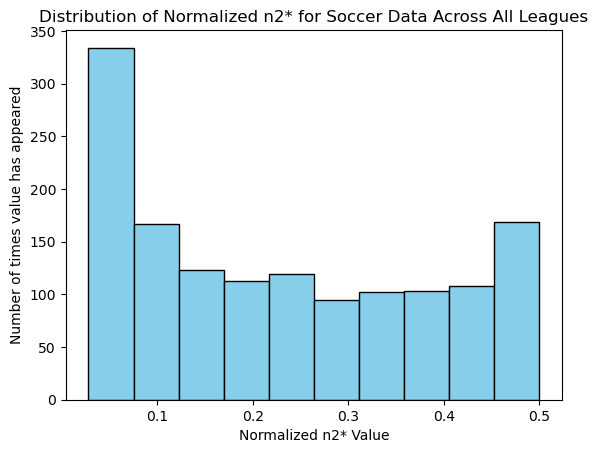

In [32]:
plt.hist(soccer['normalized_n2*'],color='skyblue', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* for Soccer Data Across All Leagues')
plt.show()

### Premier League

In [37]:
pl_normalized_n2_counts = pl_soccer['normalized_n2*'].value_counts().reset_index()
pl_normalized_n2_counts

,normalized_n2*,count
0,0.500000,15
1,0.035714,12
2,0.034483,12
3,0.032258,11
4,0.033333,11
...,...,...
145,0.235294,1
146,0.300000,1
147,0.468750,1
148,0.275862,1


In [39]:
pl_normalized_n2_summary = pl_soccer['normalized_n2*'].describe().reset_index()
pl_normalized_n2_summary

,index,normalized_n2*
0,count,502.000000
1,mean,0.221664
2,std,0.151867
3,min,0.027778
4,25%,0.074074
5,50%,0.200000
6,75%,0.347826
7,max,0.500000


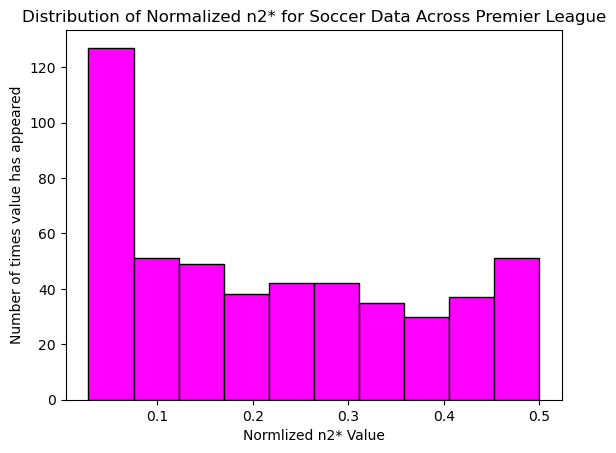

In [40]:
plt.hist(pl_soccer['normalized_n2*'],color='magenta', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normlized n2* Value')
plt.title('Distribution of Normalized n2* for Soccer Data Across Premier League')
plt.show()

### La Liga

In [44]:
la_liga_normalized_n2_counts = la_liga_soccer['normalized_n2*'].value_counts().reset_index()
la_liga_normalized_n2_counts

,normalized_n2*,count
0,0.500000,19
1,0.035714,13
2,0.100000,11
3,0.333333,11
4,0.034483,11
...,...,...
138,0.387097,1
139,0.272727,1
140,0.432432,1
141,0.088235,1


In [45]:
la_liga_normalized_n2_summary = la_liga_soccer['normalized_n2*'].describe().reset_index()
la_liga_normalized_n2_summary

,index,normalized_n2*
0,count,481.000000
1,mean,0.227346
2,std,0.157350
3,min,0.027778
4,25%,0.076923
5,50%,0.200000
6,75%,0.375000
7,max,0.500000


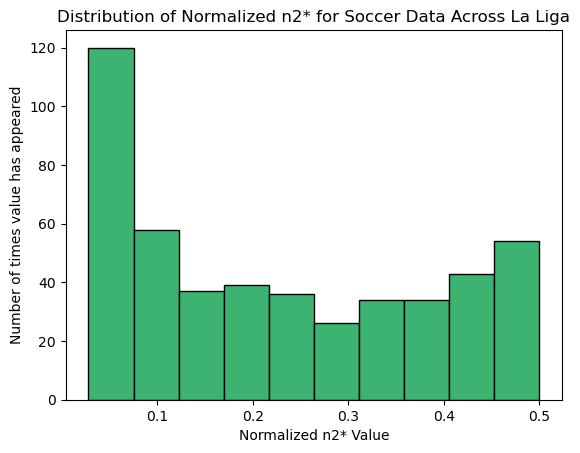

In [47]:
plt.hist(la_liga_soccer['normalized_n2*'],color='mediumseagreen', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* for Soccer Data Across La Liga')
plt.show()

### Bundesliga

In [51]:
bundesliga_normalized_n2_counts = bundesliga_soccer['normalized_n2*'].value_counts().reset_index()
bundesliga_normalized_n2_counts

,normalized_n2*,count
0,0.500000,25
1,0.250000,15
2,0.035714,13
3,0.333333,12
4,0.083333,12
...,...,...
123,0.100000,1
124,0.233333,1
125,0.350000,1
126,0.217391,1


In [52]:
bundesliga_normalized_n2_summary = bundesliga_soccer['normalized_n2*'].describe().reset_index()
bundesliga_normalized_n2_summary

,index,normalized_n2*
0,count,450.000000
1,mean,0.240433
2,std,0.156094
3,min,0.032258
4,25%,0.083333
5,50%,0.230769
6,75%,0.375000
7,max,0.500000


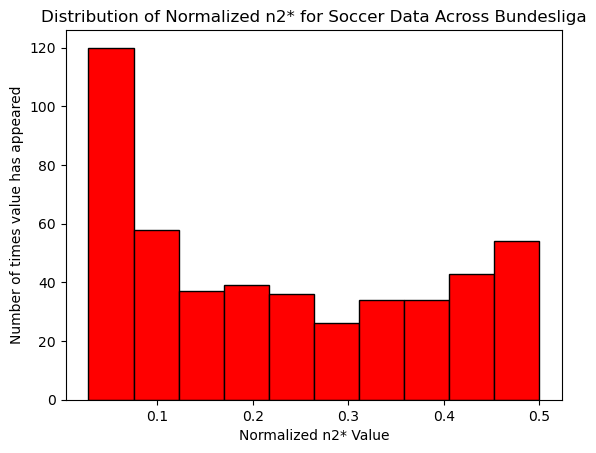

In [54]:
plt.hist(la_liga_soccer['normalized_n2*'],color='red', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* for Soccer Data Across Bundesliga')
plt.show()

# US Leagues 

In [72]:
us_leagues['League'].unique()

array(['NBA', 'MLB'], dtype=object)

In [74]:
us_leagues['normalized_n2*'] = us_leagues['n2*']/us_leagues['n']
us_leagues

,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3,n1*,c1*,n2*,c2*,normalized_n2*
0,NBA,2015,Orlando Magic,"[0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, ...",82,41,41,35,20,15,3.764011,7.567749,5.617978,41,3.764011,41,7.567749,0.500000
1,NBA,2015,Houston Rockets,"[0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, ...",82,41,41,41,21,20,2.000000,2.423658,2.057613,35,2.717839,35,3.976260,0.426829
2,NBA,2015,Oklahoma City Thunder,"[1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, ...",82,41,41,55,29,26,2.749747,4.159434,3.300330,8,11.926959,8,32.797102,0.097561
3,NBA,2015,Sacramento Kings,"[0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, ...",82,41,41,33,18,15,2.639310,4.005520,3.105590,39,4.190481,39,8.918303,0.475610
4,NBA,2015,Utah Jazz,"[0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, ...",82,41,41,40,18,22,1.277825,1.232172,1.136364,5,4.923305,2,12.320543,0.024390
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4318,NBA,1982,Indiana Pacers,"[1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, ...",82,41,41,20,13,7,5.464184,16.280440,9.009009,37,12.046809,37,53.259359,0.451220
4319,NBA,1982,Washington Bullets,"[0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, ...",82,41,41,42,18,24,1.158671,1.101917,1.064963,3,2.075934,1,6.610688,0.012195
4320,NBA,1982,Dallas Mavericks,"[1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, ...",82,41,41,38,19,19,1.774389,2.000000,1.808318,11,18.279912,11,45.312997,0.134146
4321,NBA,1982,Denver Nuggets,"[0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, ...",82,41,41,45,19,26,1.115894,1.064008,1.047120,15,1.812723,15,2.236664,0.182927


## N2* Analysis

### Across All Leagues

In [78]:
us_leagues_n2_counts = us_leagues['n2*'].value_counts().reset_index()
us_leagues_n2_counts

,n2*,count
0,1,473
1,2,342
2,3,247
3,4,208
4,5,165
...,...,...
76,62,11
77,51,10
78,64,8
79,60,8


In [80]:
us_leagues_n2_summary = us_leagues['n2*'].describe().reset_index()
us_leagues_n2_summary

,index,n2*
0,count,4323.000000
1,mean,21.942401
2,std,22.439876
3,min,1.000000
4,25%,4.000000
5,50%,13.000000
6,75%,35.000000
7,max,81.000000


### NBA

In [83]:
us_leagues.columns

Index(['League', 'Season', 'Team', 'Sequence', 'n', 'n1', 'n2', 'k', 'k1',
       'k2', 'c1', 'c2', 'c3', 'n1*', 'c1*', 'n2*', 'c2*', 'normalized_n2*'],
      dtype='object')

In [85]:
nba = us_leagues.loc[us_leagues['League'] == 'NBA']
nba['n2*'].value_counts().reset_index()

,n2*,count
0,1,240
1,2,167
2,3,132
3,4,103
4,41,98
5,5,85
6,6,70
7,7,60
8,8,53
9,9,47


In [87]:
nba_n2_summary = nba['n2'].describe().reset_index()
nba_n2_summary

,index,n2
0,count,2017.000000
1,mean,40.554289
2,std,2.773377
3,min,25.000000
4,25%,41.000000
5,50%,41.000000
6,75%,41.000000
7,max,48.000000


### MLB

In [90]:
mlb = us_leagues.loc[us_leagues['League'] == 'MLB']
mlb['n2*'].value_counts().reset_index()

,n2*,count
0,1,233
1,2,175
2,3,115
3,4,105
4,5,80
...,...,...
76,51,10
77,64,8
78,43,8
79,60,8


In [92]:
mlb_n2_summary = mlb['n2'].describe().reset_index()
mlb_n2_summary

,index,n2
0,count,2306.000000
1,mean,78.390286
2,std,7.017386
3,min,29.000000
4,25%,77.000000
5,50%,81.000000
6,75%,81.000000
7,max,82.000000


## Normalized N2* Analysis

### Across All Leagues

In [96]:
us_leagues['normalized_n2*'].value_counts().reset_index()

,normalized_n2*,count
0,0.500000,176
1,0.012195,175
2,0.006173,146
3,0.024390,126
4,0.012346,102
...,...,...
667,0.352564,1
668,0.304348,1
669,0.111801,1
670,0.248447,1


In [98]:
us_leagues['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,4323.000000
1,mean,0.183212
2,std,0.168713
3,min,0.006135
4,25%,0.031056
5,50%,0.121951
6,75%,0.329268
7,max,0.500000


<function matplotlib.pyplot.show(close=None, block=None)>

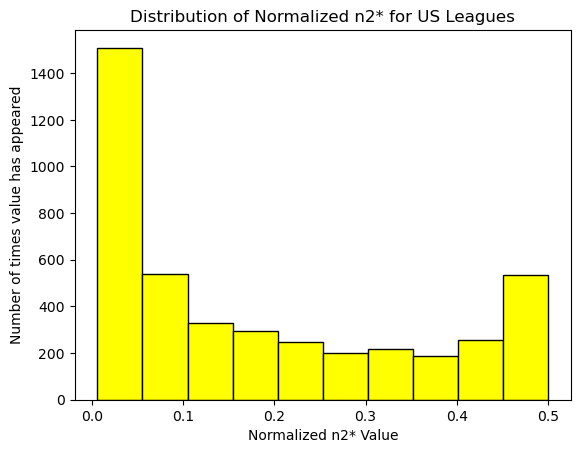

In [99]:
plt.hist(us_leagues['normalized_n2*'],color='yellow', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* for US Leagues')
plt.show

### NBA

In [101]:
nba['normalized_n2*'].value_counts().reset_index()

,normalized_n2*,count
0,0.012195,175
1,0.024390,126
2,0.500000,116
3,0.036585,89
4,0.048780,74
...,...,...
232,0.106061,1
233,0.484848,1
234,0.272727,1
235,0.303030,1


In [102]:
nba['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,2017.000000
1,mean,0.191826
2,std,0.168418
3,min,0.010638
4,25%,0.036585
5,50%,0.134146
6,75%,0.341463
7,max,0.500000


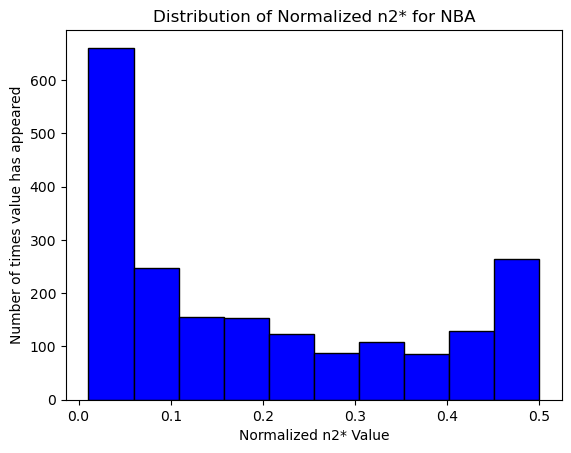

In [105]:
plt.hist(nba['normalized_n2*'],color='blue', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* for NBA')
plt.show()

### MLB

In [110]:
mlb['normalized_n2*'].value_counts().reset_index()

,normalized_n2*,count
0,0.006173,146
1,0.012346,100
2,0.018519,74
3,0.500000,60
4,0.024691,60
...,...,...
476,0.012821,1
477,0.478261,1
478,0.096970,1
479,0.121212,1


In [111]:
mlb['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,2306.000000
1,mean,0.175678
2,std,0.168646
3,min,0.006135
4,25%,0.024730
5,50%,0.104938
6,75%,0.320988
7,max,0.500000


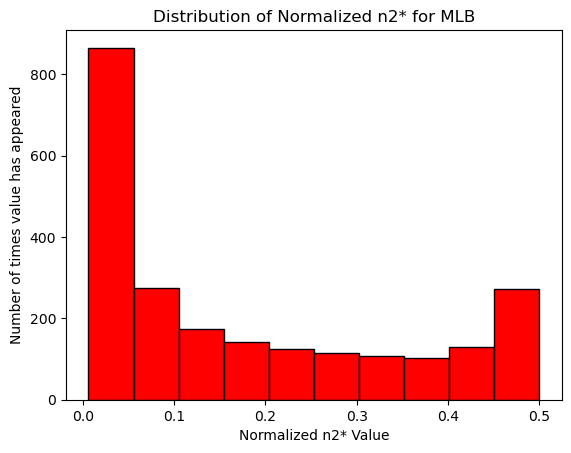

In [112]:
plt.hist(mlb['normalized_n2*'],color='red', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* for MLB')
plt.show()

In [113]:
combined = pd.concat([soccer, us_leagues], ignore_index=True)

In [118]:
combined['normalized_n2*'].value_counts().reset_index()

,normalized_n2*,count
0,0.500000,235
1,0.012195,175
2,0.006173,146
3,0.024390,126
4,0.012346,102
...,...,...
748,0.180556,1
749,0.354167,1
750,0.096970,1
751,0.479167,1


In [119]:
combined['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,5756.000000
1,mean,0.194727
2,std,0.166629
3,min,0.006135
4,25%,0.040000
5,50%,0.146018
6,75%,0.341463
7,max,0.500000


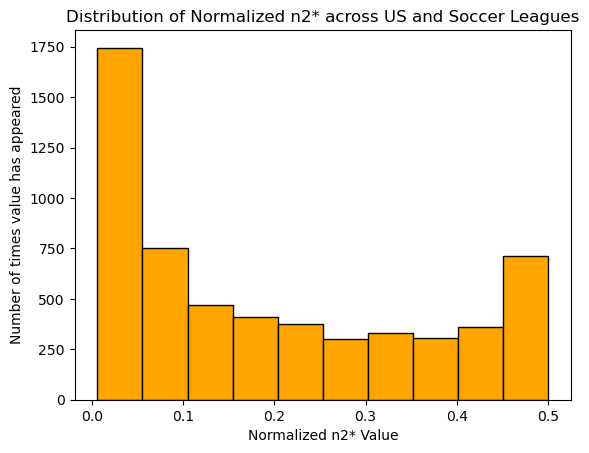

In [120]:
plt.hist(combined['normalized_n2*'],color='orange', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* across US and Soccer Leagues')
plt.show()

# Normalized N2 for top 100 c2* scores

## Soccer

In [274]:
soccer_top100_c2 = soccer.nlargest(100, 'c2*').reset_index(drop=True)
soccer_top100_c2

,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3,n1*,c1*,n2*,c2*,normalized_n2*
0,La_Liga,2008,Real Madrid,"[0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, ...",35,18,17,25,13,12,1.784106,2.186198,1.597444,5,525.218750,5.0,14914.763581,0.142857
1,La_Liga,2017,Barcelona,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",29,15,14,28,15,13,2.576282,6.845833,2.141328,2,14.754386,2.0,10836.868981,0.068966
2,Premier_League,2024,Liverpool,"[1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",29,15,14,25,14,11,3.303469,8.021735,3.703704,2,52.562500,2.0,8058.975755,0.068966
3,Premier_League,2000,Man United,"[1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, ...",30,15,15,24,13,11,2.842218,5.535406,3.278689,3,125.000000,3.0,7670.781330,0.100000
4,Bundesliga,2019,Schalke 04,"[0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, ...",22,11,11,9,8,1,37.844079,832.591030,259.067358,10,192.660767,10.0,5447.173990,0.454545
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Premier_League,2020,Man United,"[1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, ...",31,16,15,25,13,12,1.731940,2.150886,1.587302,3,10.216392,3.0,68.787914,0.096774
96,Bundesliga,2005,Schalke 04,"[1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, ...",21,11,10,16,9,7,2.280991,3.806680,2.192982,5,10.945664,5.0,67.793836,0.238095
97,Bundesliga,2006,Aachen,"[0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, ...",27,14,13,9,5,4,1.811467,2.546632,1.831502,7,17.085937,7.0,67.278490,0.259259
98,La_Liga,2002,Alaves,"[0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, ...",27,14,13,8,6,2,4.746731,16.909507,7.841907,12,11.204119,12.0,66.243818,0.444444


In [278]:
soccer_top100_c2['normalized_n2*'].value_counts().reset_index()

,normalized_n2*,count
0,0.321429,5
1,0.400000,3
2,0.444444,3
3,0.068966,3
4,0.142857,2
...,...,...
73,0.441176,1
74,0.285714,1
75,0.230769,1
76,0.035714,1


In [280]:
soccer_top100_c2['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,100.000000
1,mean,0.245991
2,std,0.142644
3,min,0.030303
4,25%,0.123162
5,50%,0.240690
6,75%,0.371528
7,max,0.500000


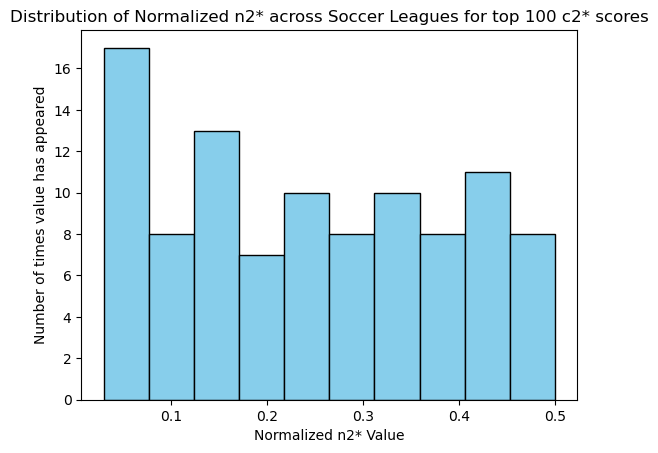

In [282]:
plt.hist(soccer_top100_c2['normalized_n2*'],color='skyblue', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* across Soccer Leagues for top 100 c2* scores')
plt.show()

### Premier League

In [285]:
PL_top100_c2 = pl_soccer.nlargest(100, 'c2*').reset_index(drop=True)

In [287]:
PL_top100_c2['normalized_n2*'].value_counts().reset_index()

,normalized_n2*,count
0,0.066667,4
1,0.344828,3
2,0.296296,3
3,0.100000,3
4,0.178571,3
...,...,...
64,0.130435,1
65,0.034483,1
66,0.115385,1
67,0.071429,1


In [289]:
PL_top100_c2['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,100.000000
1,mean,0.244728
2,std,0.137225
3,min,0.030303
4,25%,0.123750
5,50%,0.227778
6,75%,0.344828
7,max,0.500000


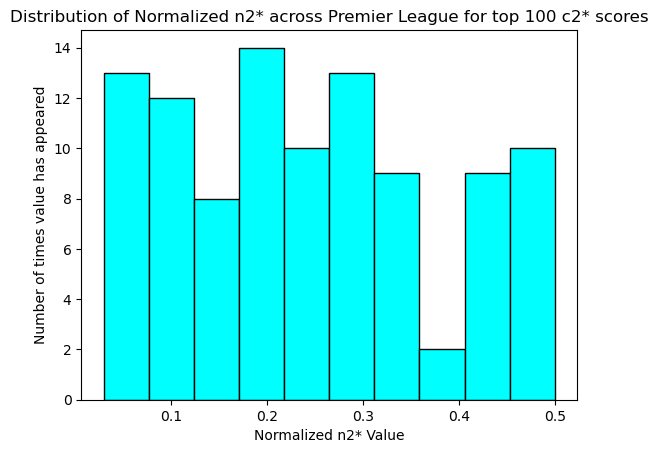

In [291]:
plt.hist(PL_top100_c2['normalized_n2*'],color='Aqua', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* across Premier League for top 100 c2* scores')
plt.show()

### La Liga

In [293]:
LaLiga_top100_c2 = la_liga_soccer.nlargest(100, 'c2*').reset_index(drop=True)

In [295]:
LaLiga_top100_c2['normalized_n2*'].value_counts().reset_index()

,normalized_n2*,count
0,0.500000,6
1,0.321429,4
2,0.068966,4
3,0.206897,4
4,0.142857,3
...,...,...
58,0.093750,1
59,0.111111,1
60,0.440000,1
61,0.464286,1


In [297]:
LaLiga_top100_c2['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,100.000000
1,mean,0.251909
2,std,0.148223
3,min,0.031250
4,25%,0.137143
5,50%,0.226540
6,75%,0.381250
7,max,0.500000


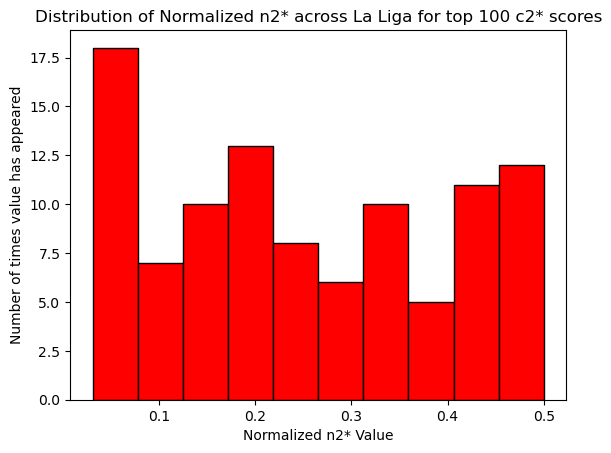

In [299]:
plt.hist(LaLiga_top100_c2['normalized_n2*'],color='Red', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* across La Liga for top 100 c2* scores')
plt.show()

### Bundesliga

In [301]:
Bundesliga_top100_c2 = bundesliga_soccer.nlargest(100, 'c2*').reset_index(drop=True)

In [303]:
Bundesliga_top100_c2['normalized_n2*'].value_counts().reset_index()

,normalized_n2*,count
0,0.250000,6
1,0.166667,3
2,0.291667,3
3,0.040000,3
4,0.083333,3
...,...,...
63,0.074074,1
64,0.214286,1
65,0.473684,1
66,0.307692,1


In [305]:
Bundesliga_top100_c2['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,100.000000
1,mean,0.245324
2,std,0.130960
3,min,0.032258
4,25%,0.153846
5,50%,0.240000
6,75%,0.352500
7,max,0.500000


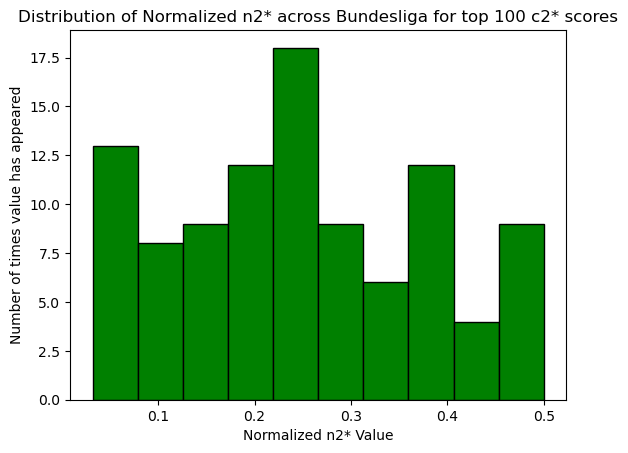

In [307]:
plt.hist(Bundesliga_top100_c2['normalized_n2*'],color='Green', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* across Bundesliga for top 100 c2* scores')
plt.show()

# US Leagues

In [310]:
us_leagues_top100_c2 = us_leagues.nlargest(100, 'c2*').reset_index(drop=True)

In [312]:
us_leagues_top100_c2['normalized_n2*'].value_counts().reset_index()

,normalized_n2*,count
0,0.402439,4
1,0.195122,3
2,0.222222,3
3,0.500000,3
4,0.365854,3
...,...,...
66,0.490683,1
67,0.339506,1
68,0.481481,1
69,0.456790,1


In [314]:
us_leagues_top100_c2['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,100.000000
1,mean,0.251376
2,std,0.139873
3,min,0.024390
4,25%,0.123080
5,50%,0.231707
6,75%,0.365048
7,max,0.500000


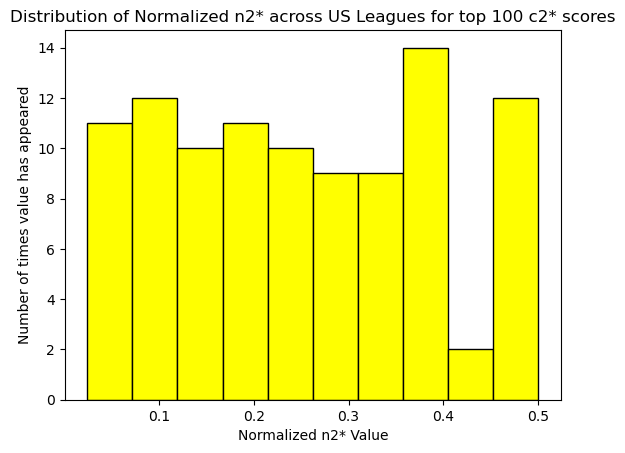

In [316]:
plt.hist(us_leagues_top100_c2['normalized_n2*'],color='Yellow', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* across US Leagues for top 100 c2* scores')
plt.show()

### MLB

In [318]:
mlb_top100_c2 = mlb.nlargest(100, 'c2*').reset_index(drop=True)

In [320]:
mlb_top100_c2['normalized_n2*'].value_counts().reset_index()

,normalized_n2*,count
0,0.160494,4
1,0.500000,3
2,0.092593,3
3,0.222222,3
4,0.084416,2
...,...,...
73,0.434783,1
74,0.296296,1
75,0.415584,1
76,0.090909,1


In [322]:
mlb_top100_c2['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,100.000000
1,mean,0.246754
2,std,0.141795
3,min,0.032680
4,25%,0.121813
5,50%,0.222222
6,75%,0.359568
7,max,0.500000


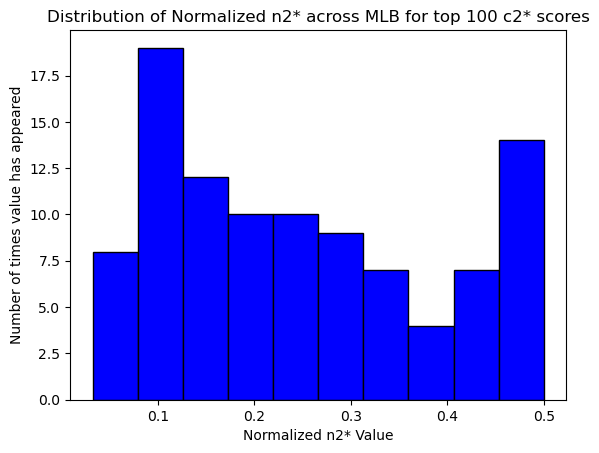

In [324]:
plt.hist(mlb_top100_c2['normalized_n2*'],color='blue', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* across MLB for top 100 c2* scores')
plt.show()

### NBA

In [326]:
nba_top100_c2 = nba.nlargest(100, 'c2*').reset_index(drop=True)

In [328]:
nba_top100_c2['normalized_n2*'].value_counts().reset_index()

,normalized_n2*,count
0,0.121951,6
1,0.402439,5
2,0.048780,5
3,0.097561,4
4,0.073171,3
5,0.365854,3
6,0.134146,3
7,0.207317,3
8,0.024390,3
9,0.195122,3


In [330]:
nba_top100_c2['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,100.000000
1,mean,0.213166
2,std,0.148291
3,min,0.024390
4,25%,0.073171
5,50%,0.195122
6,75%,0.360485
7,max,0.500000


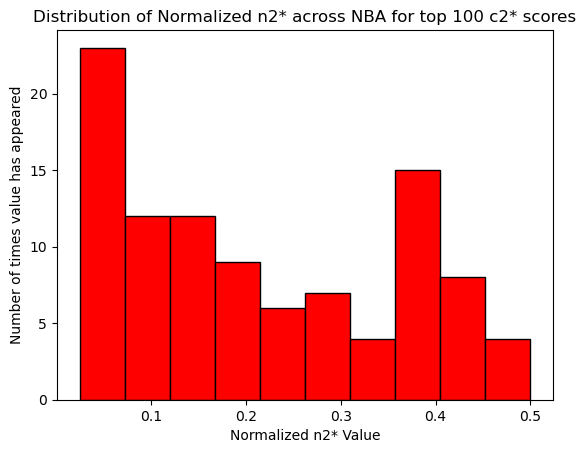

In [332]:
plt.hist(nba_top100_c2['normalized_n2*'],color='red', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* across NBA for top 100 c2* scores')
plt.show()

# Combined

In [334]:
top100_c2 = combined.nlargest(100, 'c2*').reset_index(drop=True)

In [336]:
top100_c2

,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3,n1*,c1*,n2*,c2*,normalized_n2*
0,NBA,2019,Milwaukee Bucks,"[1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, ...",73,37,36,56,32,24,8.926887,44.276737,27.777778,13,1771.133822,13.0,129918.035424,0.178082
1,NBA,1977,Portland Trail Blazers,"[1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, ...",82,41,41,58,35,23,30.541130,557.836448,273.972603,19,2112.767285,19.0,106664.310595,0.231707
2,NBA,1977,Portland Trail Blazers,"[1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, ...",82,41,41,58,35,23,30.541130,557.836448,303.030303,19,2112.767285,19.0,106664.310595,0.231707
3,MLB,2002,Baltimore Orioles,"[1,0,0,0,0,0,0,1,0,0,1,0,1,0,0,1,1,0,1,1,0,1,1...",162,81,81,67,39,28,7.741031,25.227880,19.230769,36,12691.123382,36.0,68157.368294,0.222222
4,MLB,1978,Oakland Athletics,"[0,1,0,1,1,1,1,1,0,1,1,1,1,1,1,1,1,0,0,1,1,1,1...",162,81,81,69,42,27,17.664755,116.569319,75.471698,45,2591.757040,48.0,29296.803616,0.296296
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,La_Liga,2005,Barcelona,"[1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",31,16,15,25,15,10,6.756726,35.418201,13.915948,2,26.694444,2.0,704.431466,0.064516
96,Bundesliga,2013,Bayern Munich,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",31,16,15,29,16,13,3.970886,15.265657,4.629630,6,19.067004,6.0,704.431466,0.193548
97,NBA,2006,Indiana Pacers,"[1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, ...",82,41,41,35,21,14,5.813137,16.937112,12.195122,29,87.215441,29.0,690.320353,0.353659
98,NBA,1989,New York Knicks,"[0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, ...",82,41,41,45,26,19,5.776256,16.623006,10.638298,21,73.728234,30.0,689.157451,0.365854


In [338]:
top100_c2['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,100.000000
1,mean,0.245393
2,std,0.140161
3,min,0.024390
4,25%,0.121951
5,50%,0.222222
6,75%,0.360217
7,max,0.500000


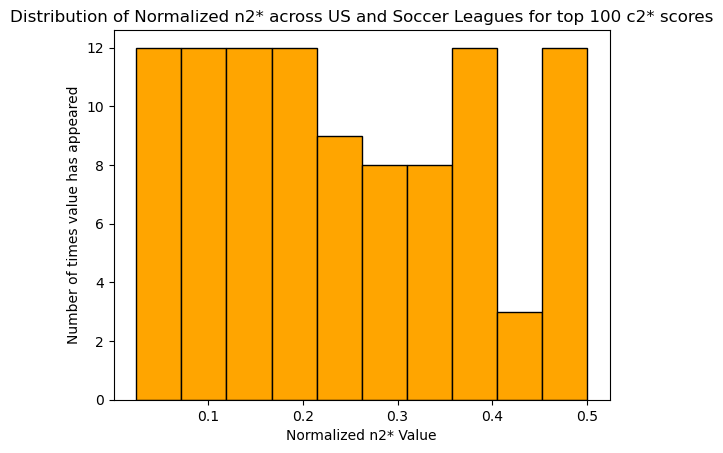

In [340]:
plt.hist(top100_c2['normalized_n2*'],color='orange', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* across US and Soccer Leagues for top 100 c2* scores')
plt.show()

# Normalized N2* for top 20 c2* scores

## Soccer

In [343]:
soccer_top20_c2 = soccer.nlargest(20, 'c2*').reset_index(drop=True)
soccer_top20_c2

,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3,n1*,c1*,n2*,c2*,normalized_n2*
0,La_Liga,2008,Real Madrid,"[0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, ...",35,18,17,25,13,12,1.784106,2.186198,1.597444,5,525.218750,5.0,14914.763581,0.142857
1,La_Liga,2017,Barcelona,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",29,15,14,28,15,13,2.576282,6.845833,2.141328,2,14.754386,2.0,10836.868981,0.068966
2,Premier_League,2024,Liverpool,"[1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",29,15,14,25,14,11,3.303469,8.021735,3.703704,2,52.562500,2.0,8058.975755,0.068966
3,Premier_League,2000,Man United,"[1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, ...",30,15,15,24,13,11,2.842218,5.535406,3.278689,3,125.000000,3.0,7670.781330,0.100000
4,Bundesliga,2019,Schalke 04,"[0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, ...",22,11,11,9,8,1,37.844079,832.591030,259.067358,10,192.660767,10.0,5447.173990,0.454545
5,La_Liga,2003,Real Madrid,"[1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, ...",31,16,15,21,13,8,5.618992,20.707720,9.865825,5,286.291510,5.0,4965.432102,0.161290
6,Bundesliga,2009,Leverkusen,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, ...",20,10,10,15,10,5,12.799688,203.598097,62.500000,7,77.649289,7.0,4611.101344,0.350000
7,Premier_League,2005,Chelsea,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, ...",34,17,17,29,16,13,4.291079,13.669947,5.681818,2,46.240000,2.0,4474.954321,0.058824
8,La_Liga,2008,Barcelona,"[0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",32,16,16,27,15,12,4.304088,13.876647,5.780347,2,40.960000,2.0,2904.807020,0.062500
9,Bundesliga,2014,Bayern Munich,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, ...",30,15,15,25,14,11,4.319296,14.119837,6.050705,4,61.714286,4.0,2591.121823,0.133333


In [345]:
soccer_top20_c2['normalized_n2*'].value_counts().reset_index()

,normalized_n2*,count
0,0.068966,2
1,0.142857,1
2,0.117647,1
3,0.321429,1
4,0.260870,1
5,0.448276,1
6,0.193548,1
7,0.064516,1
8,0.103448,1
9,0.440000,1


In [347]:
soccer_top20_c2['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,20.000000
1,mean,0.206899
2,std,0.154528
3,min,0.058824
4,25%,0.082459
5,50%,0.138095
6,75%,0.328571
7,max,0.500000


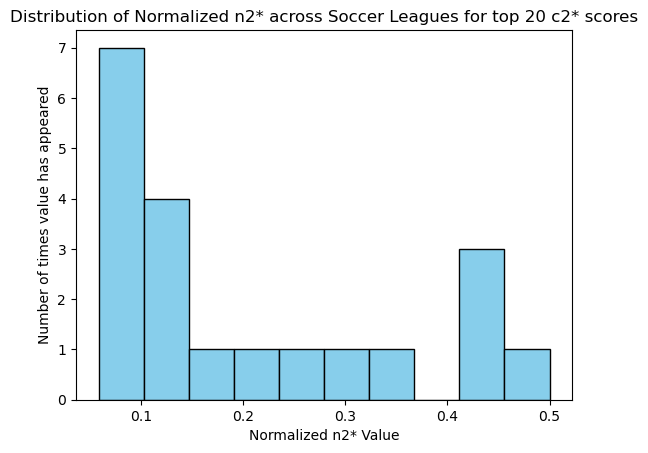

In [349]:
plt.hist(soccer_top20_c2['normalized_n2*'],color='skyblue', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* across Soccer Leagues for top 20 c2* scores')
plt.show()

### Premier League

In [351]:
PL_top20_c2 = pl_soccer.nlargest(20, 'c2*').reset_index(drop=True)

In [353]:
PL_top20_c2['normalized_n2*'].value_counts().reset_index()

,normalized_n2*,count
0,0.030303,2
1,0.103448,2
2,0.068966,1
3,0.482759,1
4,0.137931,1
5,0.481481,1
6,0.500000,1
7,0.444444,1
8,0.290323,1
9,0.241379,1


In [355]:
PL_top20_c2['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,20.000000
1,mean,0.227190
2,std,0.167539
3,min,0.030303
4,25%,0.085217
5,50%,0.189655
6,75%,0.338542
7,max,0.500000


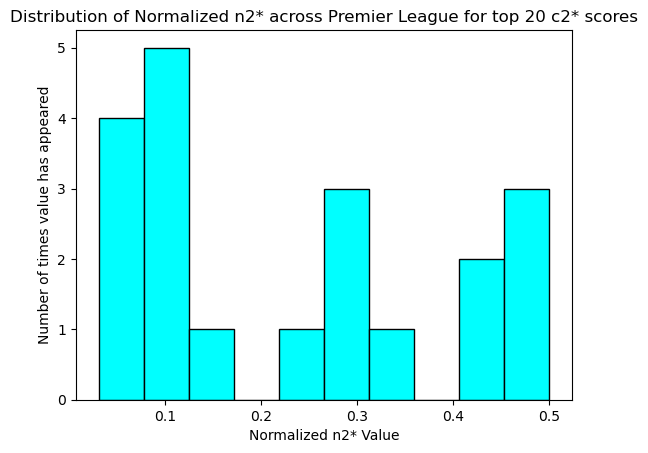

In [357]:
plt.hist(PL_top20_c2['normalized_n2*'],color='Aqua', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* across Premier League for top 20 c2* scores')
plt.show()

### La Liga

In [360]:
LaLiga_top20_c2 = la_liga_soccer.nlargest(20, 'c2*').reset_index(drop=True)

In [362]:
LaLiga_top20_c2['normalized_n2*'].value_counts().reset_index()

,normalized_n2*,count
0,0.321429,3
1,0.142857,1
2,0.031250,1
3,0.285714,1
4,0.441176,1
5,0.437500,1
6,0.482759,1
7,0.333333,1
8,0.066667,1
9,0.500000,1


In [364]:
LaLiga_top20_c2['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,20.000000
1,mean,0.263480
2,std,0.160733
3,min,0.031250
4,25%,0.105477
5,50%,0.303571
6,75%,0.409375
7,max,0.500000


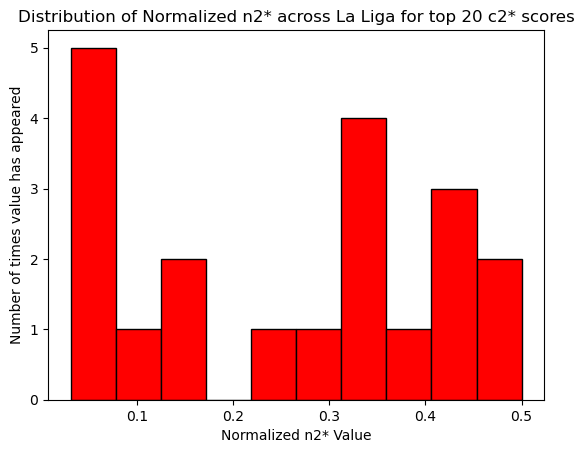

In [366]:
plt.hist(LaLiga_top20_c2['normalized_n2*'],color='Red', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* across La Liga for top 20 c2* scores')
plt.show()

### Bundesliga

In [368]:
Bundesliga_top20_c2 = bundesliga_soccer.nlargest(20, 'c2*').reset_index(drop=True)

In [370]:
Bundesliga_top20_c2['normalized_n2*'].value_counts().reset_index()

,normalized_n2*,count
0,0.454545,1
1,0.350000,1
2,0.200000,1
3,0.370370,1
4,0.068966,1
5,0.375000,1
6,0.444444,1
7,0.240000,1
8,0.035714,1
9,0.230769,1


In [372]:
Bundesliga_top20_c2['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,20.000000
1,mean,0.236105
2,std,0.141026
3,min,0.032258
4,25%,0.148718
5,50%,0.211111
6,75%,0.371528
7,max,0.454545


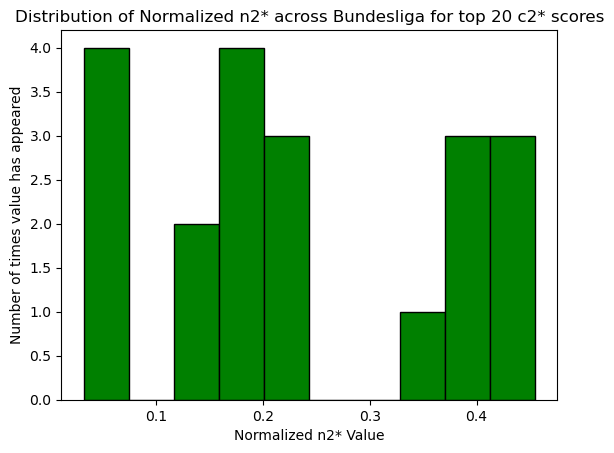

In [374]:
plt.hist(Bundesliga_top20_c2['normalized_n2*'],color='Green', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* across Bundesliga for top 20 c2* scores')
plt.show()

# US Leagues

In [377]:
us_leagues_top20_c2 = us_leagues.nlargest(20, 'c2*').reset_index(drop=True)

In [379]:
us_leagues_top20_c2['normalized_n2*'].value_counts().reset_index()

,normalized_n2*,count
0,0.358696,2
1,0.231707,2
2,0.178082,1
3,0.214286,1
4,0.086420,1
5,0.233766,1
6,0.123457,1
7,0.048780,1
8,0.146341,1
9,0.308642,1


In [381]:
us_leagues_top20_c2['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,20.000000
1,mean,0.217746
2,std,0.092897
3,min,0.048780
4,25%,0.142164
5,50%,0.226965
6,75%,0.287037
7,max,0.358696


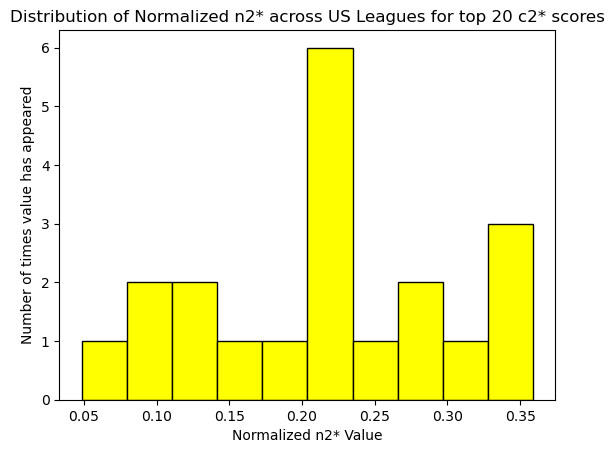

In [383]:
plt.hist(us_leagues_top20_c2['normalized_n2*'],color='Yellow', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* across US Leagues for top 20 c2* scores')
plt.show()

### MLB

In [386]:
mlb_top20_c2 = mlb.nlargest(20, 'c2*').reset_index(drop=True)

In [388]:
mlb_top20_c2['normalized_n2*'].value_counts().reset_index()

,normalized_n2*,count
0,0.086420,2
1,0.222222,1
2,0.233766,1
3,0.500000,1
4,0.296552,1
5,0.364780,1
6,0.111801,1
7,0.388889,1
8,0.166667,1
9,0.123457,1


In [390]:
mlb_top20_c2['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,20.000000
1,mean,0.234487
2,std,0.114607
3,min,0.084416
4,25%,0.128086
5,50%,0.226018
6,75%,0.299574
7,max,0.500000


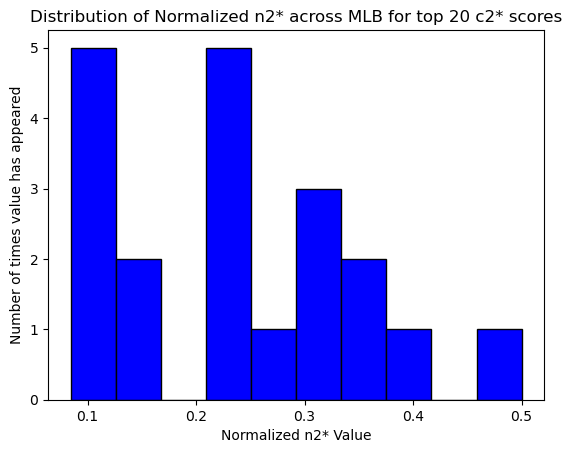

In [392]:
plt.hist(mlb_top20_c2['normalized_n2*'],color='blue', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* across MLB for top 20 c2* scores')
plt.show()

### NBA

In [395]:
nba_top20_c2 = nba.nlargest(20, 'c2*').reset_index(drop=True)

In [397]:
nba_top20_c2['normalized_n2*'].value_counts().reset_index()

,normalized_n2*,count
0,0.231707,2
1,0.358696,2
2,0.048780,2
3,0.195122,2
4,0.402439,2
5,0.459770,2
6,0.178082,1
7,0.146341,1
8,0.256098,1
9,0.500000,1


In [399]:
nba_top20_c2['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,20.000000
1,mean,0.266360
2,std,0.136351
3,min,0.048780
4,25%,0.173196
5,50%,0.231707
6,75%,0.369631
7,max,0.500000


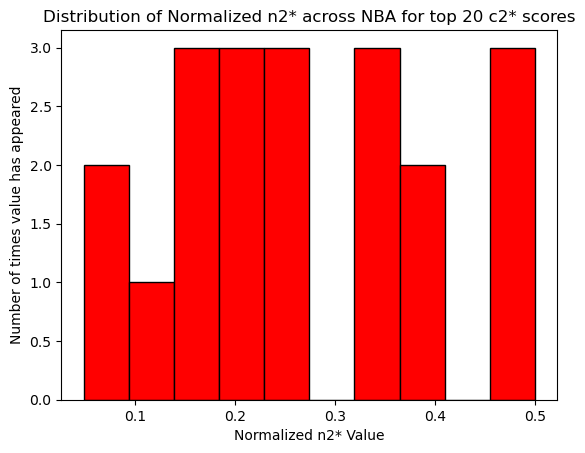

In [401]:
plt.hist(nba_top20_c2['normalized_n2*'],color='red', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* across NBA for top 20 c2* scores')
plt.show()

# Combined

In [404]:
top20_c2 = combined.nlargest(20, 'c2*').reset_index(drop=True)

In [406]:
top20_c2

,League,Season,Team,Sequence,n,n1,n2,k,k1,k2,c1,c2,c3,n1*,c1*,n2*,c2*,normalized_n2*
0,NBA,2019,Milwaukee Bucks,"[1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, ...",73,37,36,56,32,24,8.926887,44.276737,27.777778,13,1771.133822,13.0,129918.035424,0.178082
1,NBA,1977,Portland Trail Blazers,"[1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, ...",82,41,41,58,35,23,30.541130,557.836448,273.972603,19,2112.767285,19.0,106664.310595,0.231707
2,NBA,1977,Portland Trail Blazers,"[1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, ...",82,41,41,58,35,23,30.541130,557.836448,303.030303,19,2112.767285,19.0,106664.310595,0.231707
3,MLB,2002,Baltimore Orioles,"[1,0,0,0,0,0,0,1,0,0,1,0,1,0,0,1,1,0,1,1,0,1,1...",162,81,81,67,39,28,7.741031,25.227880,19.230769,36,12691.123382,36.0,68157.368294,0.222222
4,MLB,1978,Oakland Athletics,"[0,1,0,1,1,1,1,1,0,1,1,1,1,1,1,1,1,0,0,1,1,1,1...",162,81,81,69,42,27,17.664755,116.569319,75.471698,45,2591.757040,48.0,29296.803616,0.296296
5,NBA,1962,Los Angeles Lakers,"[1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, ...",92,46,46,58,35,23,20.737029,209.551838,124.688279,33,596.179715,33.0,27248.741232,0.358696
6,NBA,1962,Los Angeles Lakers,"[1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, ...",92,46,46,58,35,23,20.737029,209.551838,116.686114,33,596.179715,33.0,27248.741232,0.358696
7,La_Liga,2008,Real Madrid,"[0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, ...",35,18,17,25,13,12,1.784106,2.186198,1.597444,5,525.218750,5.0,14914.763581,0.142857
8,MLB,2017,Los Angeles Dodgers,"[1,0,1,1,0,0,1,0,1,0,1,1,0,0,0,1,0,0,1,0,1,0,1...",162,81,81,104,53,51,2.224125,2.691455,2.288330,35,980.742645,35.0,12283.325438,0.216049
9,La_Liga,2017,Barcelona,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",29,15,14,28,15,13,2.576282,6.845833,2.141328,2,14.754386,2.0,10836.868981,0.068966


In [408]:
top20_c2['normalized_n2*'].describe().reset_index()

,index,normalized_n2*
0,count,20.000000
1,mean,0.222834
2,std,0.108807
3,min,0.068966
4,25%,0.139550
5,50%,0.219136
6,75%,0.299383
7,max,0.454545


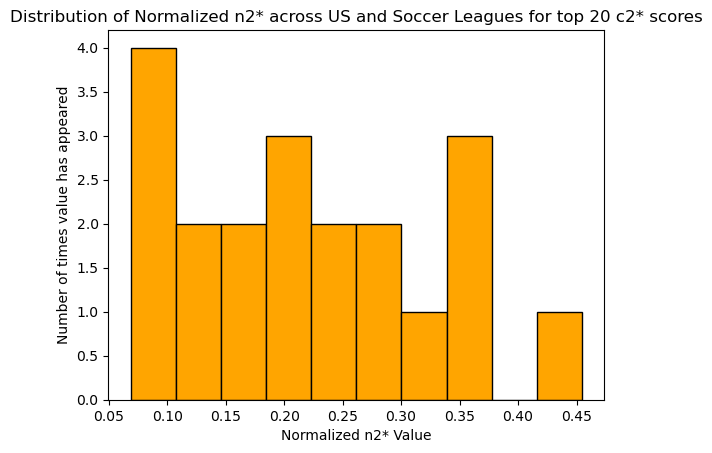

In [410]:
plt.hist(top20_c2['normalized_n2*'],color='orange', edgecolor='black')
plt.ylabel('Number of times value has appeared')
plt.xlabel('Normalized n2* Value')
plt.title('Distribution of Normalized n2* across US and Soccer Leagues for top 20 c2* scores')
plt.show()